In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)
L=10
matrix_cold=np.ones((L,L),dtype=int)
matrix_hot=np.random.randint(1,11,size=(L,L))

In [3]:
def matrix_total_E(matrix):
    L=matrix.shape[0]
    #left_coordinators=matrix[x,(y-1)%L]
    #right_coordinators=matrix[x,(y+1)%L]
    #up_coordinators=matrix[(x-1)%L,y]
    #down_coordinators=matrix[(x+1)%L,y]
    total_E=0
    for x in range(L):
        for y in range(L):
            if matrix[x,y]==matrix[x,(y+1)%L]:
                total_E-=1
            if matrix[x,y]==matrix[(x+1)%L,y]:
                total_E-=1
    return total_E

In [4]:
def metropolis_sweep(matrix,beta,q):
    beta=1/T
    L=matrix.shape[0]
    sweep_dE=0
    #for change of E(delta_E) in each change

    for _ in range(L*L):
        x=np.random.randint(0,L)
        y=np.random.randint(0,L)
        neighbors = [
            matrix[(x + 1) % L, y],
            matrix[(x - 1) % L, y],
            matrix[x, (y + 1) % L],
            matrix[x, (y - 1) % L]
                ]
        old_values=matrix[x,y]
        new_values=np.random.randint(1, q + 1)
        match_old = sum(1 for n in neighbors if n == old_values)
        match_new = sum(1 for n in neighbors if n == new_values)
        delta_E=-((match_new)-(match_old))
        
    
        if delta_E<=0 or np.random.rand()<np.exp(-beta*delta_E):
            matrix[x,y]=new_values
            sweep_dE+=delta_E
        
    return sweep_dE


In [5]:
def run_sweep_cold(matrix,n):
    beta=1/T
    sweep_dE=0
    total_dE_cold=0
    E_value_cold=[]
    original_E_cold=matrix_total_E(matrix)
    E_value_cold.append(original_E_cold)
    #print(f"original energy of cold start is:{original_E_cold:.2f}")
    for i in range(n-1):
        dE_cold=metropolis_sweep(matrix_cold,beta,q)
        original_E_cold+=dE_cold
        E_value_cold.append(original_E_cold)
    #print(f"Energy at the endpoint is{original_E_cold:.2f}")
    return E_value_cold


In [6]:
def run_sweep_hot(matrix,n):
    beta=1/T
    sweep_dE=0
    total_dE_hot=0
    E_value_hot=[]
    original_E_hot=matrix_total_E(matrix)
    E_value_hot.append(original_E_hot)
    #print(f"original energy of hot start is:{original_E_hot:.2f}")
    for i in range(n-1):
        dE_hot=metropolis_sweep(matrix_hot,beta,q)
        original_E_hot+=dE_hot
        E_value_hot.append(original_E_hot)
    #print(f"Energy at the endpoint is{original_E_hot:.2f}")
    return E_value_hot

In [7]:
q=10
T_c=1/np.log(1+np.sqrt(q))
print(T_c)

0.7012315679302166


In [8]:
T=1
n=100

In [9]:
E_value_hot=run_sweep_hot(matrix_hot,n)
E_value_cold=run_sweep_cold(matrix_cold,n)

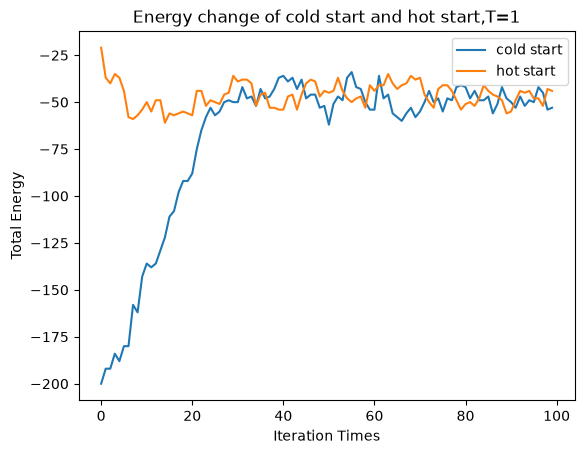

In [10]:
x=range(n)
plt.plot(x,E_value_cold, label="cold start")
plt.xlabel("Iteration Times")
plt.ylabel("Total Energy")
#plt.ylim(-15000,3000)
plt.plot(x,E_value_hot,label="hot start")
plt.title("Energy change of cold start and hot start,T=1")
plt.legend()
plt.show()

In [11]:
matrix_cold=np.ones((L,L),dtype=int)
matrix_hot=np.random.randint(1,11,size=(L,L))

T=0.2
beta=1/T

In [12]:
E_value_hot=run_sweep_hot(matrix_hot,n=100)
E_value_cold=run_sweep_cold(matrix_cold,n=100)

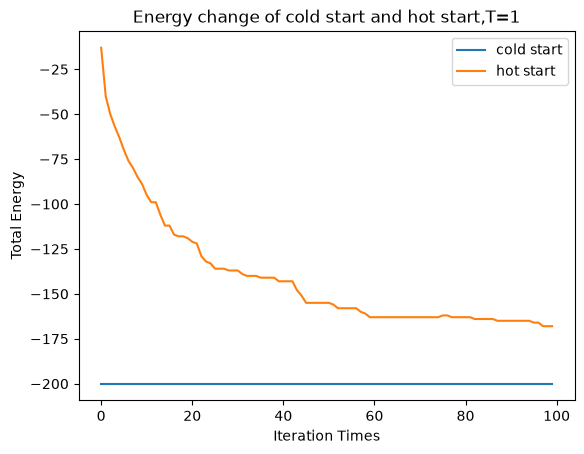

In [13]:
x=range(n)
plt.plot(x,E_value_cold, label="cold start")
plt.xlabel("Iteration Times")
plt.ylabel("Total Energy")
#plt.ylim(-15000,3000)
plt.plot(x,E_value_hot,label="hot start")
plt.title("Energy change of cold start and hot start,T=1")
plt.legend()

In [14]:
matrix_cold=np.ones((L,L),dtype=int)
matrix_hot=np.random.randint(1,11,size=(L,L))
E_list=[]
for t in np.arange(0,3,0.1):
    T=t
    beta=1/T
    E_value_cold=run_sweep_cold(matrix_cold,n=100)
    E_list.append(E_value_cold[-1])

Text(0, 0.5, 'Endpoint Energy')

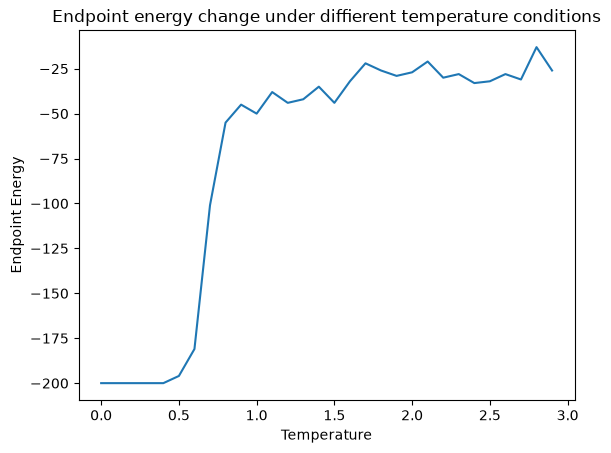

In [15]:
T_list=np.arange(0,3,0.1)
plt.plot(T_list,E_list)
plt.title("Endpoint energy change under diffierent temperature conditions")
plt.xlabel("Temperature")
plt.ylabel("Endpoint Energy")

In [16]:
q=2
T_c=1/np.log(1+np.sqrt(q))
print(T_c)

1.134592657106511


In [17]:
matrix_cold=np.ones((L,L),dtype=int)
matrix_hot=np.random.randint(1,11,size=(L,L))
E_list=[]
for t in np.arange(0,3,0.1):
    T=t
    beta=1/T
    E_value_cold=run_sweep_cold(matrix_cold,n=100)
    E_list.append(E_value_cold[-1])

Text(0, 0.5, 'Endpoint Energy')

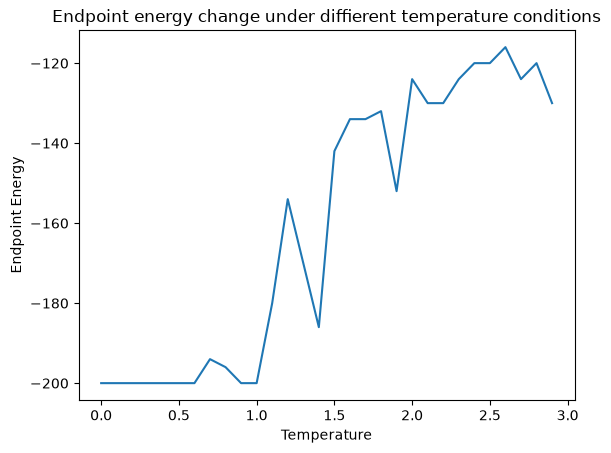

In [18]:
T_list=np.arange(0,3,0.1)
plt.plot(T_list,E_list)
plt.title("Endpoint energy change under diffierent temperature conditions")
plt.xlabel("Temperature")
plt.ylabel("Endpoint Energy")